In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
plt.switch_backend('Agg')

import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import LabelEncoder

# Configure inline plotting
%matplotlib inline

# Set visual styles
sns.set(style="whitegrid")

In [2]:
data = pd.read_csv(r'C:\Users\anast\.cache\kagglehub\datasets\ahmadrosyidalfualdi\student-mental-health-dataset\versions\4\Student Mental health.csv')
data

,Timestamp,Choose your gender,Age,What is your course?,Your current year of Study,What is your CGPA?,Marital status,Do you have Depression?,Do you have Anxiety?,Do you have Panic attack?,Did you seek any specialist for a treatment?
0,8/7/2020 12:02,Female,18.0,Engineering,year 1,3.00 - 3.49,No,Yes,No,Yes,No
1,8/7/2020 12:04,Male,21.0,Islamic education,year 2,3.00 - 3.49,No,No,Yes,No,No
2,8/7/2020 12:05,Male,19.0,BIT,Year 1,3.00 - 3.49,No,Yes,Yes,Yes,No
3,8/7/2020 12:06,Female,22.0,Laws,year 3,3.00 - 3.49,Yes,Yes,No,No,No
4,8/7/2020 12:13,Male,23.0,Mathemathics,year 4,3.00 - 3.49,No,No,No,No,No
...,...,...,...,...,...,...,...,...,...,...,...
96,13/07/2020 19:56:49,Female,21.0,BCS,year 1,3.50 - 4.00,No,No,Yes,No,No
97,13/07/2020 21:21:42,Male,18.0,Engineering,Year 2,3.00 - 3.49,No,Yes,Yes,No,No
98,13/07/2020 21:22:56,Female,19.0,Nursing,Year 3,3.50 - 4.00,Yes,Yes,No,Yes,No
99,13/07/2020 21:23:57,Female,23.0,Pendidikan Islam,year 4,3.50 - 4.00,No,No,No,No,No


In [3]:
data=data.drop('Timestamp',axis=1)
if data.empty:
    raise ValueError('The input dataset is empty. Please check the file and its path.')

if set(data['Do you have Anxiety?'].str.lower().unique()) <= {"yes", "no"}:
    data['Do you have Anxiety?'] = data['Do you have Anxiety?'].str.lower().map({'yes': 1, 'no': 0})
else:
    le = LabelEncoder()
    data['Do you have Anxiety?'] = le.fit_transform(data['Do you have Anxiety?'])

df = pd.get_dummies(data, drop_first=True)

print("\nData after encoding:")
display(df.head())


Data after encoding:


,Age,Do you have Anxiety?,Choose your gender_Male,What is your course?_Accounting,What is your course?_BCS,What is your course?_BENL,What is your course?_BIT,What is your course?_Banking Studies,What is your course?_Benl,What is your course?_Biomedical science,...,Your current year of Study_year 4,What is your CGPA?_2.00 - 2.49,What is your CGPA?_2.50 - 2.99,What is your CGPA?_3.00 - 3.49,What is your CGPA?_3.50 - 4.00,What is your CGPA?_3.50 - 4.00,Marital status_Yes,Do you have Depression?_Yes,Do you have Panic attack?_Yes,Did you seek any specialist for a treatment?_Yes
0,18.0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,1,1,0
1,21.0,1,1,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
2,19.0,1,1,0,0,0,1,0,0,0,...,0,0,0,1,0,0,0,1,1,0
3,22.0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,1,1,0,0
4,23.0,0,1,0,0,0,0,0,0,0,...,1,0,0,1,0,0,0,0,0,0


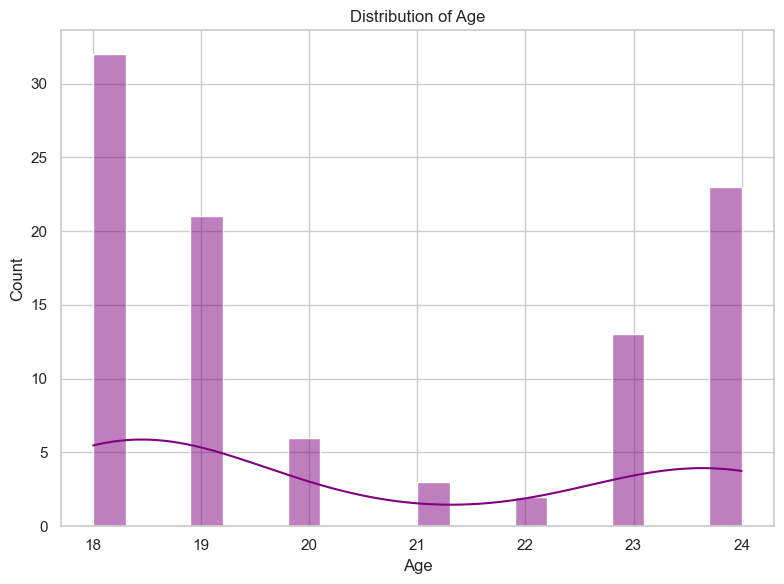

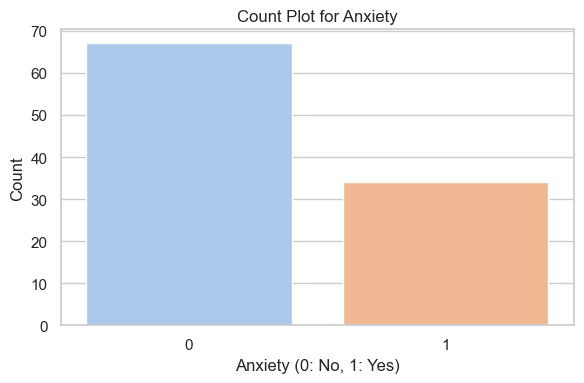

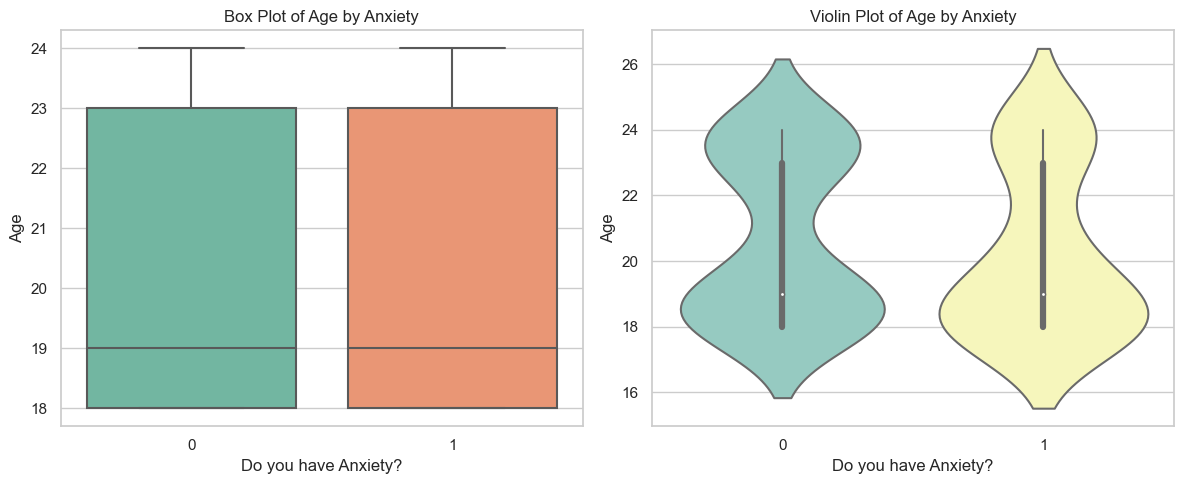

In [4]:
plt.figure(figsize=(8, 6))
sns.histplot(df['Age'], kde=True, bins=20, color='purple')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Count plot for the target variable 'Suicide Attempt'
plt.figure(figsize=(6, 4))
sns.countplot(x=df['Do you have Anxiety?'], palette='pastel')
plt.title('Count Plot for Anxiety')
plt.xlabel('Anxiety (0: No, 1: Yes)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Box plot and violin plot for Age grouped by Suicide Attempt
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x=df['Do you have Anxiety?'], y=df['Age'], palette='Set2')
plt.title('Box Plot of Age by Anxiety')

plt.subplot(1, 2, 2)
sns.violinplot(x=df['Do you have Anxiety?'], y=df['Age'], palette='Set3')
plt.title('Violin Plot of Age by Anxiety')

plt.tight_layout()
plt.show()

Accuracy Score: 0.6500


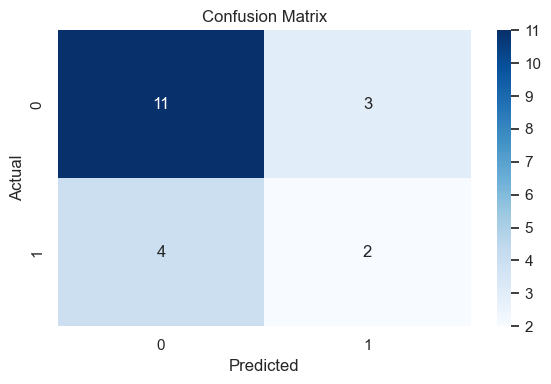

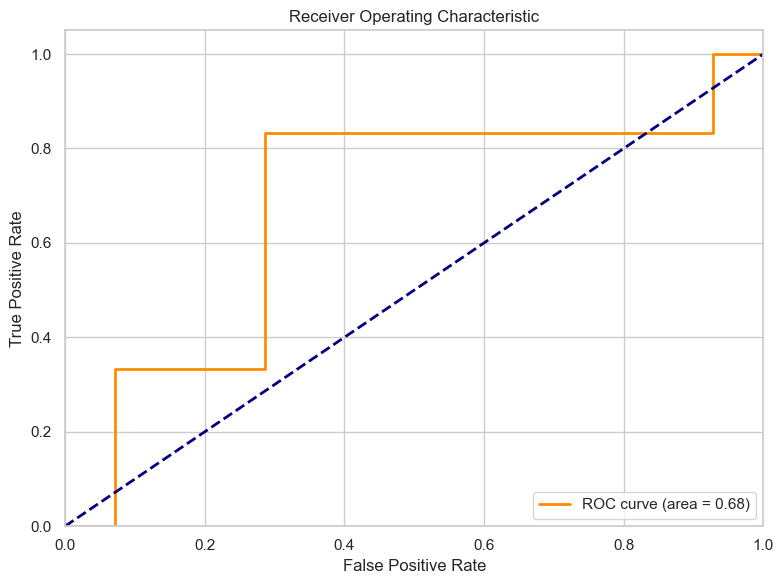

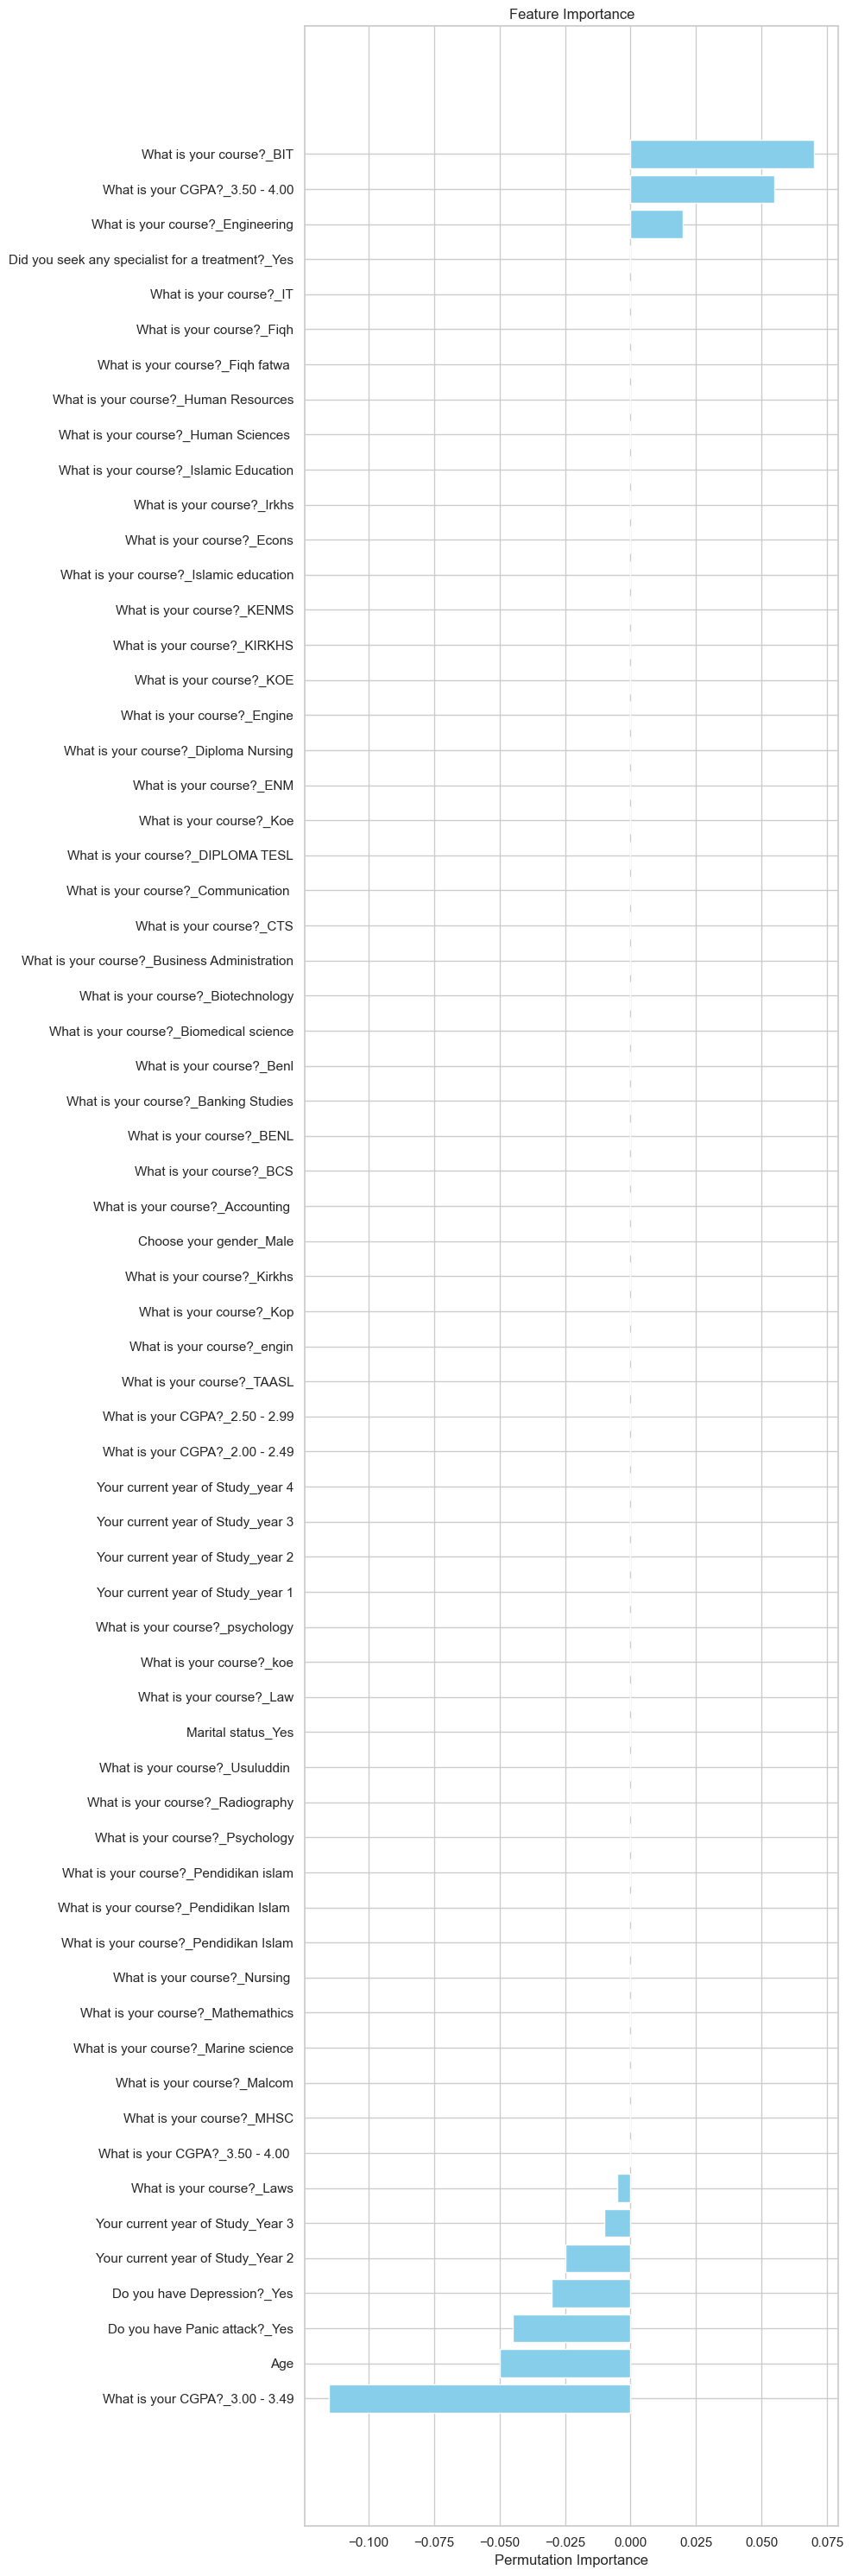

In [6]:
df.dropna(inplace=True)

X = df.drop('Do you have Anxiety?', axis=1)
y = df['Do you have Anxiety?']

if X.shape[0] == 0:
    raise ValueError('The feature matrix is empty after dropping NaNs. Check your data for extensive missing values.')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

if X_train.shape[0] == 0:
    raise ValueError('Training set is empty after splitting. Adjust the test_size or check the input data.')

model = LogisticRegression(max_iter=10000, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy Score: {accuracy:.4f}')

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

if set(y_test.unique()) <= {0, 1}:
    y_probs = model.predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()
else:
    print('ROC Curve requires binary labels. Please ensure that the target variable is encoded correctly.')

result = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42, scoring='accuracy')
importance_df = pd.DataFrame({'feature': X_test.columns, 'importance': result.importances_mean})
importance_df = importance_df.sort_values(by='importance', ascending=True)

plt.figure(figsize=(10, 30))
plt.barh(importance_df['feature'], importance_df['importance'], color='skyblue')
plt.xlabel('Permutation Importance')
plt.title('Feature Importance')
plt.tight_layout()
plt.show()